## Постановка задачи

Исследуйте данные и сделайте выводы по полученным результатам. Подкрепите свои рассуждения и выводы визуализациями и с помощью статистического тестирования проверьте, являются ли выводы статистически значимыми.

В процессе своего анализа вы должны:

    Выяснить, какие факторы влияют на зарплату специалиста Data Scientist.
    А также ответить на ключевые вопросы HR-агентства:
        Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
        Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
        Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
        Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

Если вы найдёте в данных интересные закономерности, также отметьте их в своём анализе.

Продемонстрируйте использование разных тестов для проверки статистической значимости сделанных выводов:

        тесты для количественного признака:
                для одной выборки;
                для двух выборок;
                для нескольких выборок;
        тест для категориальных признаков.


На каждый вопрос необходимо ответить с уровнем значимости $\alpha=0.05$.

In [2]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2") 

In [3]:
# загружаем датасет
data = pd.read_csv('./data/ds_salaries.csv')
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [6]:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

# Удаляем дубликаты:
data = data.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(data.shape))

Количество дубликатов: 0
Размер таблицы после удаления дубликатов: (607, 12)


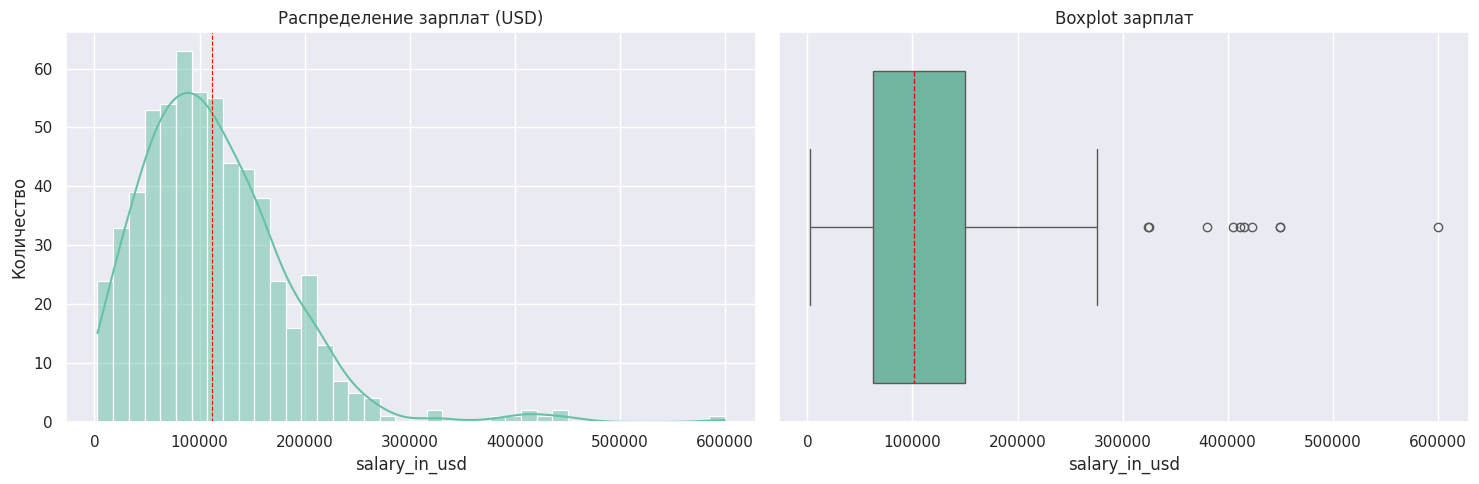

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
sns.histplot(data['salary_in_usd'], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Распределение зарплат (USD)")
axes[0].set_xlabel("salary_in_usd")
axes[0].set_ylabel("Количество")
axes[0].axvline(data['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

# Boxplot
sns.boxplot(x=data['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set_title("Boxplot зарплат")
axes[1].set_xlabel("salary_in_usd")

plt.tight_layout()
plt.show()

In [8]:
data_agg = data['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['Размер зарплат']
data_agg

,Размер зарплат
count,607.00
mean,112297.87
std,70957.26
min,2859.00
25%,62726.00
50%,101570.00
75%,150000.00
max,600000.00


In [16]:
stat, p = stats.normaltest(data['salary_in_usd'])

print("Statistic =", stat)
print("p-value =", p)


Statistic = 237.48886966589322
p-value = 2.6912075675231334e-52


Распределение зарплат отлично от нормального, имеются выбросы, сильная правосторонняя асиметрия

# Распределение по годам

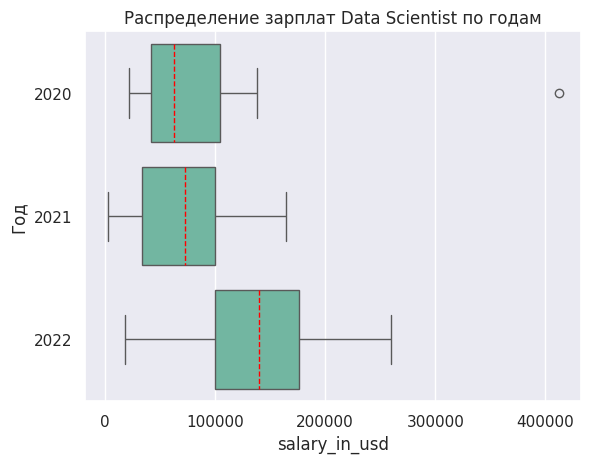

In [10]:
df_ds = data[data['job_title'] == 'Data Scientist']

ax = sns.boxplot(df_ds, x='salary_in_usd', y='work_year', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(ylabel='Год')
plt.title('Распределение зарплат Data Scientist по годам')
plt.show()

Наблюдается рост, особенно в 2022

# Cравнение Data Scientist vs Data Engineer за 2022

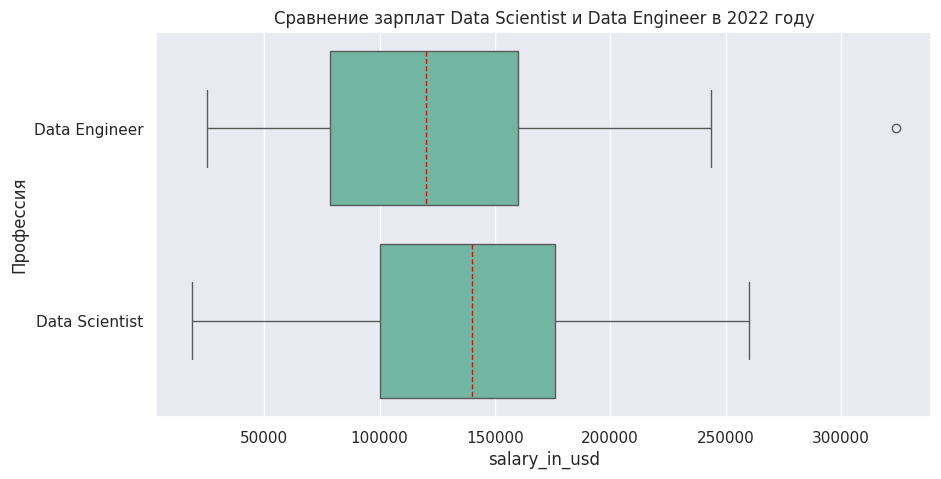

In [11]:
df_2022 = data[
    (data['work_year'] == 2022) &
    (data['job_title'].isin(["Data Scientist", "Data Engineer"]))
]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_2022,
    x="salary_in_usd",
    y="job_title",
    orient="h",
    medianprops={"color": "red", "linestyle": "--"} 
)

plt.title("Сравнение зарплат Data Scientist и Data Engineer в 2022 году")
plt.xlabel("salary_in_usd")
plt.ylabel("Профессия")
plt.show()


Data Scientist превышает Data Engineer

# Сравнение Зарплаты Data Scientist в компаниях разных размеров

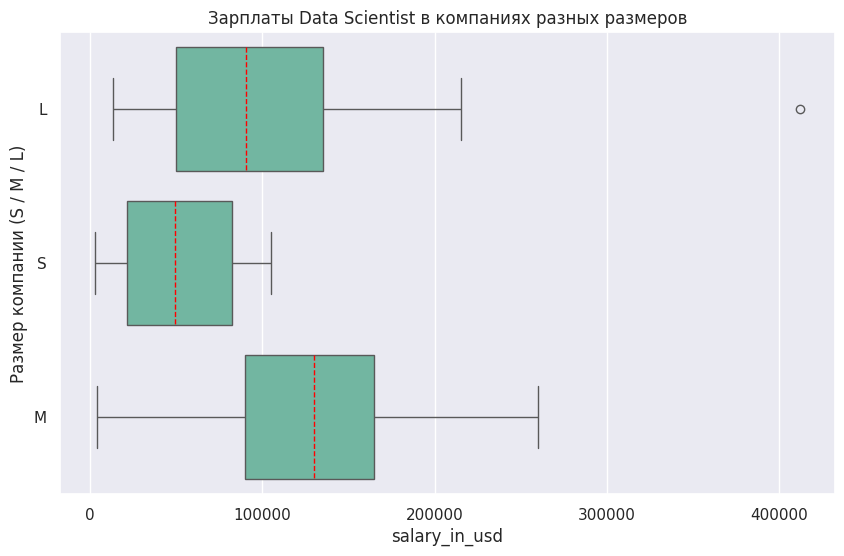

In [12]:
# фильтруем только Data Scientist
df_ds = data[data["job_title"] == "Data Scientist"]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_ds,
    x="salary_in_usd",
    y="company_size",
    orient="h",
    medianprops={"color": "red", "linestyle": "--"}
)

plt.title("Зарплаты Data Scientist в компаниях разных размеров")
plt.xlabel("salary_in_usd")
plt.ylabel("Размер компании (S / M / L)")
plt.show()


# **Статистические тесты**

## Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

$$H_0: \text{Между годами нет положительной динамики}.$$

$$H_1: \text{Зарплаты ростут по годам}.$$


In [25]:
# Выбор теста:
# 3 группы (проверяем НЕ различия, а тренд роста)
# данные ненормальные
# Spearman rank correlation (односторонний тест: rho > 0)



from scipy.stats import spearmanr

# Фильтруем только Data Scientist
ds = data[data['job_title'] == 'Data Scientist']

# Считаем ранговую корреляцию Спирмена
rho, p_two_sided = spearmanr(ds['work_year'], ds['salary_in_usd'])

# Нам нужен ОДНОСТОРОННИЙ тест (rho > 0)
p_one_sided = p_two_sided / 2 if rho > 0 else 1.0

print("Коэффициент Спирмена (rho):", rho)
print("p-value (двусторонний):", p_two_sided)
print("p-value (односторонний, тест на РОСТ):", p_one_sided)

if rho > 0 and p_one_sided < alpha:
    print("Вывод: отвергаем H₀. Зарплаты DS растут по годам.")
else:
    print("Вывод: нет оснований отвергать H₀. Рост зарплат не подтверждается.")


Коэффициент Спирмена (rho): 0.5130422968460621
p-value (двусторонний): 5.700514508451385e-11
p-value (односторонний, тест на РОСТ): 2.8502572542256926e-11
Вывод: отвергаем H₀. Зарплаты DS растут по годам.


## Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

$$H_0: \text{Зарплаты Data Scientist не выше, чем у Data Engineer.}.$$

$$H_1: \text{Зарплаты Data Scientist выше, чем у Data Engineer}.$$

In [32]:
# Выбор теста:
# 2 группы
# данные ненормальные
# группы независимые
# проверяем гипотезу DS > DE
# используем Mann–Whitney U test (alternative='greater')


from scipy.stats import mannwhitneyu

# Фильтруем 2022 год
df_2022 = data[data['work_year'] == 2022]

# Выборки зарплат
ds = df_2022[df_2022['job_title'] == 'Data Scientist']['salary_in_usd']
de = df_2022[df_2022['job_title'] == 'Data Engineer']['salary_in_usd']

# Односторонний Mann–Whitney: DS > DE
_, p = mannwhitneyu(ds, de, alternative='greater')

print("p-value:", p)

if p < alpha:
    print("Отвергаем H₀: зарплаты DS выше, чем DE в 2022 году.")
else:
    print("Не отвергаем H₀: нет статистических оснований утверждать, что зарплаты DS выше.")


p-value: 0.0773245890781616
Не отвергаем H₀: нет статистических оснований утверждать, что зарплаты DS выше.


## Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

$$H_0: \text{Распределения зарплат DS одинаковы в компаниях различных размеров.}.$$

$$H_1: \text{Хотя бы одно распределение отличается}.$$

In [33]:
#### Выбор теста:
# 3 группы
# данные ненормальные
# группы независимые
# используем тест Kruskal–Wallis


from scipy.stats import kruskal

# Фильтруем только Data Scientist
ds = data[data['job_title'] == 'Data Scientist']

# Выделяем группы по размерам компании
ds_S = ds[ds['company_size'] == 'S']['salary_in_usd']
ds_M = ds[ds['company_size'] == 'M']['salary_in_usd']
ds_L = ds[ds['company_size'] == 'L']['salary_in_usd']

# Статистический тест
_, p = kruskal(ds_S, ds_M, ds_L)

print("p-value:", p)

alpha = 0.05

if p < alpha:
    print("Отвергаем H₀: зарплаты DS отличаются между размерами компаний.")
else:
    print("Не отвергаем H₀: статистических различий нет.")


p-value: 7.934227201485946e-07
Отвергаем H₀: зарплаты DS отличаются между размерами компаний.


## Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

$$H_0: \text{Распределение DS и DE одинаково во всех размерах компаний}.$$

$$H_1: \text{Распределение DS и DE зависит от размера компании}.$$

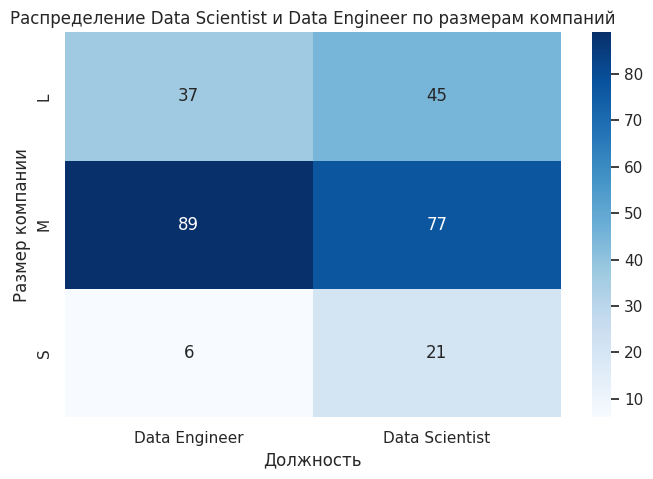

In [36]:
# Фильтруем только DS и DE
df = data[data['job_title'].isin(['Data Scientist', 'Data Engineer'])].copy()

# Кросс-таблица
table = pd.crosstab(df['company_size'], df['job_title'])

# Тепловая карта
plt.figure(figsize=(8, 5))
sns.heatmap(table, annot=True, fmt='d', cmap='Blues')
plt.title('Распределение Data Scientist и Data Engineer по размерам компаний')
plt.ylabel('Размер компании')
plt.xlabel('Должность')
plt.show()


In [40]:
# Выбор теста:
# 2 категориальные переменные
# группы независимые
# цель: проверить, зависит ли распределение должностей от размера компании
# подходит X2 независ.


from scipy.stats import chi2_contingency

_, p, _, _ = chi2_contingency(table)

print("p-value:", p)

if p < alpha:
    print("Отвергаем H₀: распределение DS и DE зависит от размера компании.")
else:
    print("Не отвергаем H₀: статистически значимой связи между размером компании и наличием DS/DE нет.")


p-value: 0.008410361897604775
Отвергаем H₀: распределение DS и DE зависит от размера компании.
